# 📊 Comprehensive Exploratory Data Analysis (EDA)
## **Objective: Behavioral Learning (BL) Data Preparation for F1 Digital Twin**

---

### **🎯 Primary Goals:**
- **Analyze telemetry data** from Assetto Corsa's built-in AI to understand optimal driving patterns
- **Prepare feature sets** for Behavioral Learning model training
- **Identify key variables** for model input/output: `Throttle`, `Brake`, `Steering`, `Gear`
- **Validate data quality** and detect anomalies that could affect model performance

### **📋 Analysis Scope:**
- **Control Variables Analysis**: Deep dive into throttle, brake, steering, and gear patterns
- **Contextual Variables**: Speed, RPM, position, and environmental factors
- **Temporal Patterns**: Lap-by-lap progression and consistency analysis  
- **Feature Engineering**: Create derived variables for enhanced model performance
- **Data Quality Assessment**: Outlier detection and missing data strategies

### **🎮 BL Model Context:**
This EDA focuses on preparing data for a **Behavioral Learning model** that will:
- **Learn from Assetto Corsa's AI** behavior patterns as a reliable baseline
- **Clone and improve** upon the existing AC AI driving capabilities
- **Predict control actions** (`Throttle`, `Brake`, `Steering`, `Gear`) based on car state
- **Serve as foundation** for our own enhanced AI implementation
- **Leverage simulator AI** as high-quality training data source

### **🏎️ Data Source Justification:**
- **AC's built-in AI** provides consistent, optimized driving patterns
- **Simulator environment** offers controlled, repeatable conditions
- **High-quality baseline** from professionally tuned racing AI
- **Foundation for improvement** rather than starting from scratch

### **📈 Expected Outcomes:**
- Clean, validated dataset ready for BL model training
- Feature importance ranking and selection recommendations
- AI behavior insights and pattern analysis
- Data preprocessing pipeline for future sessions

---

## SECTION 1: Configuration & Data Loading

### 1.1 Setup  & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from pathlib import Path
import os
import logging


# General configs
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")





### 1.2 Data Loading

In [2]:
# Construct data path using pathlib for cross-platform compatibility
ROOT = Path(__file__).resolve().parents[1] if '__file__' in globals() else Path.cwd().parent
DATA_PATH = ROOT / 'data' / 'raw' / 'telemetry_2025-09-16_20-34-00.csv'

# Load telemetry data
print(f"Loading data from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)



Loading data from: c:\Users\victo\Desktop\Documents\Cuarto Año\Primer Cuatrimestre\F1_AC_Digital_Twin\data\raw\telemetry_2025-09-16_20-34-00.csv


In [3]:
df.head()

,Timestamp,Speed_kmh,RPM,Throttle,Brake,Steering,Gear,CompletedLaps,iCurrentTime_ms,CurrentLapTime_str,...,IsInPit,IsInPitLane,TyreCompound,CarX,CarY,CarZ,Flag,SurfaceGrip,Distance,DistanceTraveled_m_Original
0,1758043928,245.59,11250,1.0,0.0,0.010,6,0,119454,1:59.454,...,False,False,Medium (M),-208.638458,-9.992744,685.714417,0,1.0,0.000,554.305
1,1758043928,247.34,11381,1.0,0.0,0.010,6,0,119553,1:59.553,...,False,False,Medium (M),-209.116684,-9.953897,678.953186,0,1.0,6.858,561.163
2,1758043928,249.21,11434,1.0,0.0,0.008,6,0,119658,1:59.658,...,False,False,Medium (M),-209.586075,-9.914362,671.725342,0,1.0,13.883,568.188
3,1758043928,250.96,11516,1.0,0.0,0.010,6,0,119754,1:59.754,...,False,False,Medium (M),-209.979019,-9.874519,665.067261,0,1.0,20.720,575.025
4,1758043928,252.72,11586,1.0,0.0,0.007,6,0,119856,1:59.856,...,False,False,Medium (M),-210.363861,-9.842612,657.942444,0,1.0,27.880,582.185


#### General Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36906 entries, 0 to 36905
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Timestamp                    36906 non-null  int64  
 1   Speed_kmh                    36906 non-null  float64
 2   RPM                          36906 non-null  int64  
 3   Throttle                     36906 non-null  float64
 4   Brake                        36906 non-null  float64
 5   Steering                     36906 non-null  float64
 6   Gear                         36906 non-null  int64  
 7   CompletedLaps                36906 non-null  int64  
 8   iCurrentTime_ms              36906 non-null  int64  
 9   CurrentLapTime_str           36906 non-null  object 
 10  iLastTime_ms                 36906 non-null  int64  
 11  iBestTime_ms                 36906 non-null  int64  
 12  DistanceTraveled_m           36906 non-null  float64
 13  LapNumberTotal  

#### Look all available columns

In [5]:
df.columns


Index(['Timestamp', 'Speed_kmh', 'RPM', 'Throttle', 'Brake', 'Steering',
       'Gear', 'CompletedLaps', 'iCurrentTime_ms', 'CurrentLapTime_str',
       'iLastTime_ms', 'iBestTime_ms', 'DistanceTraveled_m', 'LapNumberTotal',
       'CurrentSectorIndex', 'LastSectorTime_ms', 'IsInPit', 'IsInPitLane',
       'TyreCompound', 'CarX', 'CarY', 'CarZ', 'Flag', 'SurfaceGrip',
       'Distance', 'DistanceTraveled_m_Original'],
      dtype='object')

In [6]:
df.dtypes

Timestamp                        int64
Speed_kmh                      float64
RPM                              int64
Throttle                       float64
Brake                          float64
Steering                       float64
Gear                             int64
CompletedLaps                    int64
iCurrentTime_ms                  int64
CurrentLapTime_str              object
iLastTime_ms                     int64
iBestTime_ms                     int64
DistanceTraveled_m             float64
LapNumberTotal                   int64
CurrentSectorIndex               int64
LastSectorTime_ms                int64
IsInPit                           bool
IsInPitLane                       bool
TyreCompound                    object
CarX                           float64
CarY                           float64
CarZ                           float64
Flag                             int64
SurfaceGrip                    float64
Distance                       float64
DistanceTraveled_m_Origin

#### Descriptive Statistics

In [7]:
df.describe()

,Timestamp,Speed_kmh,RPM,Throttle,Brake,Steering,Gear,CompletedLaps,iCurrentTime_ms,iLastTime_ms,...,LapNumberTotal,CurrentSectorIndex,LastSectorTime_ms,CarX,CarY,CarZ,Flag,SurfaceGrip,Distance,DistanceTraveled_m_Original
count,3.690600e+04,36906.000000,36906.000000,36906.000000,36906.000000,36906.000000,36906.000000,36906.000000,36906.000000,36906.000000,...,36906.0,36906.00000,36906.000000,36906.000000,36906.000000,36906.000000,36906.0,36906.0,36906.000000,36906.000000
mean,1.758046e+09,246.675822,10779.928575,0.819470,0.084107,0.025631,6.093698,21.626592,42177.856771,82188.301225,...,0.0,0.93096,27726.461199,234.333446,-4.496270,-379.438753,0.0,1.0,2777.400967,128078.381251
std,1.071620e+03,74.201025,1348.664104,0.366457,0.261228,0.193847,2.115587,12.694976,24720.270346,13642.734001,...,0.0,0.82670,4664.005015,408.134719,3.620022,668.812608,0.0,0.0,1651.967337,73070.036449
min,1.758044e+09,0.010000,22.000000,0.000000,0.000000,-0.900000,0.000000,0.000000,6.000000,0.000000,...,0.0,0.00000,0.000000,-212.535675,-11.369493,-1277.197388,0.0,1.0,0.000000,554.305000
25%,1.758045e+09,199.292500,10520.250000,1.000000,0.000000,-0.003000,5.000000,11.000000,20886.000000,82346.000000,...,0.0,0.00000,25852.000000,-104.883438,-7.462047,-992.235718,0.0,1.0,1257.488500,65202.353500
50%,1.758046e+09,264.630000,11180.000000,1.000000,0.000000,0.002000,7.000000,22.000000,41980.500000,82415.000000,...,0.0,1.00000,26307.000000,85.490868,-4.095455,-514.319702,0.0,1.0,2654.829500,128423.238500
75%,1.758047e+09,311.237500,11604.750000,1.000000,0.000000,0.041000,8.000000,33.000000,63072.000000,82586.000000,...,0.0,2.00000,30234.000000,594.709656,-1.699043,172.595383,0.0,1.0,4164.746500,191691.917500
max,1.758048e+09,336.240000,13623.000000,1.000000,0.990000,0.871000,8.000000,44.000000,123075.000000,102775.000000,...,0.0,2.00000,50687.000000,1045.808350,1.569691,889.804749,0.0,1.0,6022.401000,254914.906000


#### Check for null values 

In [8]:
df.isnull().sum()

Timestamp                      0
Speed_kmh                      0
RPM                            0
Throttle                       0
Brake                          0
Steering                       0
Gear                           0
CompletedLaps                  0
iCurrentTime_ms                0
CurrentLapTime_str             0
iLastTime_ms                   0
iBestTime_ms                   0
DistanceTraveled_m             0
LapNumberTotal                 0
CurrentSectorIndex             0
LastSectorTime_ms              0
IsInPit                        0
IsInPitLane                    0
TyreCompound                   0
CarX                           0
CarY                           0
CarZ                           0
Flag                           0
SurfaceGrip                    0
Distance                       0
DistanceTraveled_m_Original    0
dtype: int64

#### Check categorical columns

In [9]:
df.select_dtypes(include = ["object", "bool"]).columns

Index(['CurrentLapTime_str', 'IsInPit', 'IsInPitLane', 'TyreCompound'], dtype='object')

---

## SECTION 2: Data Cleaning & Preprocessing

### 2.1 Drop all categorical columns

The following columns are removed from the dataset because they do not provide useful information for model training:

- **CurrentLapTime_str**: stored as a string; we already have a numeric version in milliseconds/seconds.
- **TyreCompound**: constant value for all rows → does not help the model.
- **IsInPit** / **IsInPitLane**: always `False` → no informative value.

Dropping these columns ensures the dataset contains only features relevant for learning and avoids unnecessary noise.

In [10]:
def drop_unused_columns(df):
    """
    Remove columns not useful for training:
    - CurrentLapTime_str: it's a string and we already have the version in milliseconds/seconds.
    - TyreCompound: always has the same value → provides no information.
    - IsInPit / IsInPitLane: always False → provides no information.
    """
    cols_to_drop = ["CurrentLapTime_str", "TyreCompound", "IsInPit", "IsInPitLane"]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors="ignore")
    print("Columns removed due to lack of informative value:", cols_to_drop)
    return df


In [11]:
df = drop_unused_columns(df)

Columns removed due to lack of informative value: ['CurrentLapTime_str', 'TyreCompound', 'IsInPit', 'IsInPitLane']


### 2.2 Check for Constant Variables that could affect training

Columns with constant values do not provide any variability and therefore 
do not contribute useful information for training machine learning models. 

This check allows us to identify these uninformative columns so we can
decide whether to drop them from the dataset, improving model efficiency 
and avoiding noise.

The expected columns will be the following:

- **LapNumberTotal**: this value in Asseto Corsa indicated the total number of laps configured for the session. As the data was taken in free practice sessions, the value is always 0 as no limit was put. 

- **Flag**: as our car is alone doing hotlaps, all the time the track has green flag. 

- **Surface Grip**: we are taking data in perfect conditions due to hardware constraints and overcomplexity for this project. Therefore, the value is always 1, so it does not provide useful information for our case. 

#### Check for Constant Columns

In [12]:
def check_constant_columns(df):
    """
    Check for columns with constant values.

    Constant columns provide no variability, so they are not useful for training models.
    Identifying this variables helps us clean the dataset and avoid unnecessary noise.
    
    """

    constant_cols = [col for col in df.columns if df[col].nunique(dropna = False) <= 1]
    if constant_cols:
        print("Columns with constant values (uninformative for modeling):", constant_cols)
    else:
        print("No constant columns detected.")
    return constant_cols


#### Eliminate Constant Columns

In [13]:
def drop_constant_columns(df):
    """
    Drop columns with constant values, as they provide no information for modeling.
    Uses check_constant_columns() to detect them first.
    """
    # Detect constant columns
    constant_cols = check_constant_columns(df)
    
    if constant_cols:
        df = df.drop(columns=constant_cols)
        print("Dropped constant columns:", constant_cols)
    else:
        print("No constant columns to drop.")
    
    return df


In [14]:
df = drop_constant_columns(df)


Columns with constant values (uninformative for modeling): ['LapNumberTotal', 'Flag', 'SurfaceGrip']
Dropped constant columns: ['LapNumberTotal', 'Flag', 'SurfaceGrip']


---

## SECTION 3: Correlation Matrix and Variable Dropping

In this section, we analyze the relationships between numerical variables in the dataset. 

1. **Correlation Matrix**: We compute the correlation matrix to visualize how numerical features relate to each other and to the target variable. This helps us understand dependencies and patterns in the data.

2. **Variable Dropping**: Features that are highly correlated with each other (e.g., correlation > 0.95) are candidates for removal. Dropping redundant variables helps reduce multicollinearity, simplifies the model, and improves generalization.

By the end of this section, we will have identified both the strength of relationships between variables and any redundant features that can safely be removed before training.


In [15]:
def plot_correlation_matrix(df: pd.DataFrame, figsize: tuple = (12, 10), cmap: str = "coolwarm") -> pd.DataFrame:
    """
    Plots the correlation matrix of numerical columns in the DataFrame
    and returns the correlation matrix as a pandas DataFrame.

    Args:
        df (pd.DataFrame): The DataFrame to analyze.
        figsize (tuple, optional): Size of the figure. Defaults to (12, 10).
        cmap (str, optional): Colormap for the heatmap. Defaults to "coolwarm".

    Returns:
        pd.DataFrame: Correlation matrix of numerical columns.
    """
    corr_matrix = df.corr()

    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=cmap)
    plt.title("Correlation Matrix")
    plt.show()

    return corr_matrix


### 3.1 Plot the Correlation Matrix

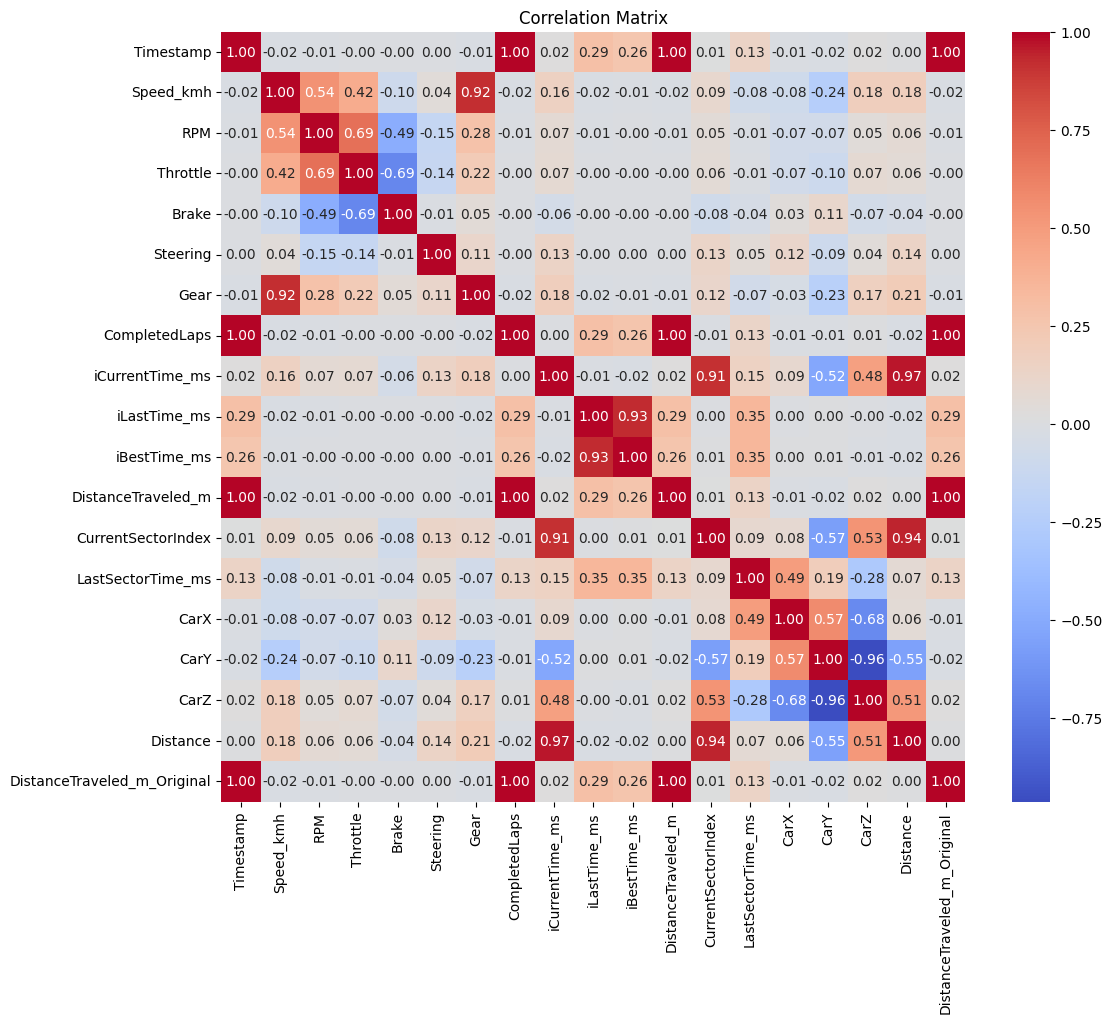

In [16]:
corr_matrix = plot_correlation_matrix(df)


### 3.2 Key Findings

The correlation matrix reveals critical redundancies requiring elimination for optimal model performance. Four variables show perfect correlation (1.00): `Timestamp`, `CompletedLaps`, `DistanceTraveled_m`, and `DistanceTraveled_m_Original`, indicating identical information in different formats. Strong correlations between timing variables (`iLastTime_ms` ↔ `iBestTime_ms`: 0.93) confirm temporal redundancy.

Expected behavioral relationships validate data quality: `Speed_kmh` ↔ `Gear` (0.92), `Throttle` ↔ `Brake` (-0.69), and `Throttle` ↔ `RPM` (0.69) demonstrate logical driving physics. Spatial coordinates show track geometry: `CarY` ↔ `CarZ` (-0.96) represents Monza's elevation profile.


### 3.3 Variable Elimination Strategy

**Eliminated variables (6 total):**
- `Timestamp`, `CompletedLaps`, `DistanceTraveled_m_Original`, `DistanceTraveled_m` - Perfect correlation redundancy
- `iLastTime_ms`, `iBestTime_ms` - Historical data irrelevant for real-time decisions  
- `LastSectorTime_ms` - Derivable from temporal progression

**Retained variables (11 total):**
- **Control**: `Throttle`, `Brake`, `Steering`, `Gear` (model outputs)
- **Vehicle State**: `Speed_kmh`, `RPM` (contextual information)
- **Spatial-Temporal**: `Distance`, `CarX`, `CarY`, `CarZ`, `iCurrentTime_ms` (position & sequencing)

This optimization eliminates all perfect correlations while preserving essential behavioral learning information, improving training efficiency and reducing overfitting risk.

In [17]:
def clean_dataframe_for_bl(df : pd.DataFrame) -> pd.DataFrame : 
    """
    Remove redundant variables identified from correlation analysis.
    
    Args:
        df: Original telemetry dataframe
    
    Returns:
        df_clean: Cleaned dataframe with redundant variables removed
    """
    variables_to_remove = [
        'Timestamp',
        'CompletedLaps', 
        'DistanceTraveled_m_Original',
        'iLastTime_ms',
        'iBestTime_ms',
        'LastSectorTime_ms',
        'DistanceTraveled_m'
    ]
    
    df_clean = df.drop(columns=variables_to_remove, errors='ignore')
    
    print(f"Original shape: {df.shape}")
    print(f"Cleaned shape: {df_clean.shape}")
    print(f"Variables removed: {variables_to_remove}")
    
    return df_clean

In [18]:
# Usage
df_clean = clean_dataframe_for_bl(df)

Original shape: (36906, 19)
Cleaned shape: (36906, 12)
Variables removed: ['Timestamp', 'CompletedLaps', 'DistanceTraveled_m_Original', 'iLastTime_ms', 'iBestTime_ms', 'LastSectorTime_ms', 'DistanceTraveled_m']


### 3.3 Plot New Corr matrix 

We generate a new correlation matrix to verify successful elimination of redundant variables and analyze the cleaned dataset without noise from previously identified multicollinearities. This visualization will confirm removal of perfect correlations (1.00) and allow focused analysis of retained variables to determine if additional cleaning is needed or if current feature relationships are suitable for behavioral learning model training.

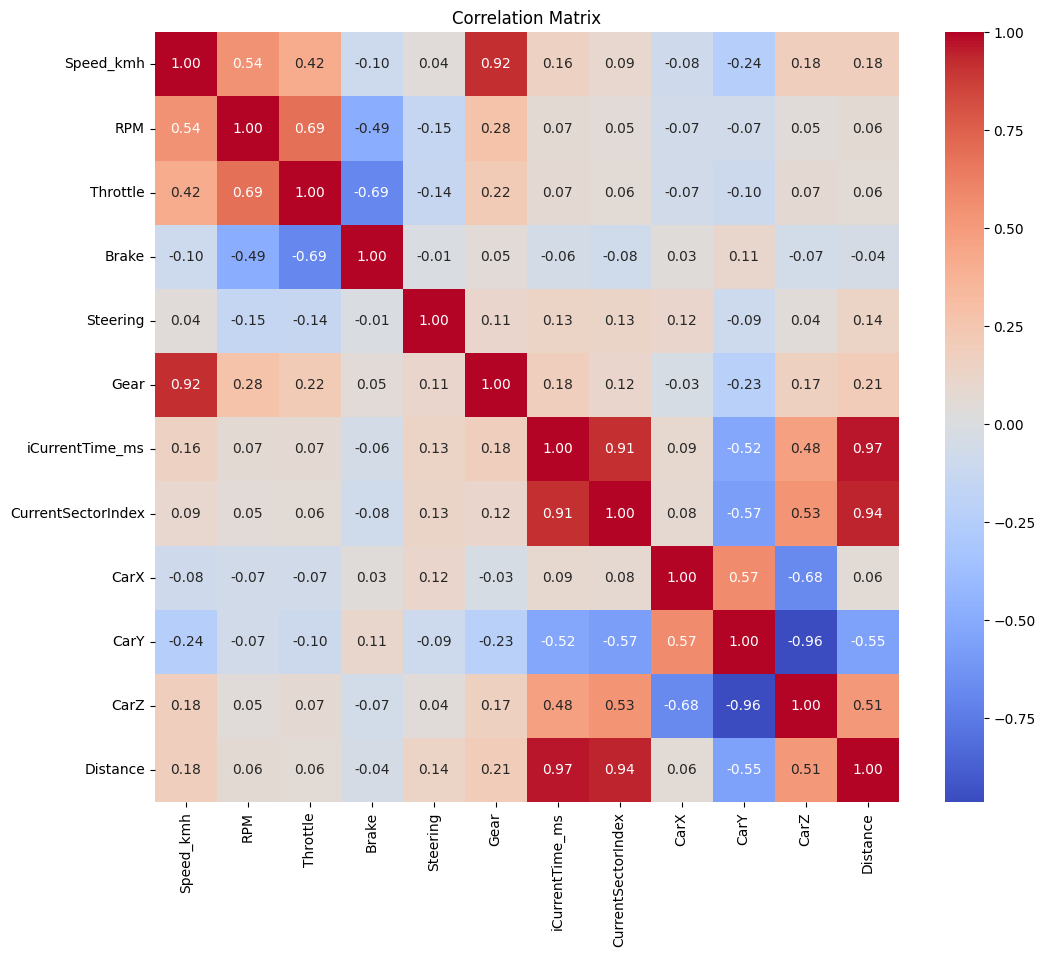

In [19]:
corr_matrix = plot_correlation_matrix(df_clean)

#### 3.3.1 New Key Findings


#### Correlation Matrix Verification Results

**✅ Elimination Successful**: All perfect correlations (1.00) removed. No remaining multicollinearity issues above 0.97 threshold.

**🔍 Key Observations**:
- Expected behavioral correlations preserved: `Speed_kmh` ↔ `Gear` (0.92), `Throttle` ↔ `Brake` (-0.69)
- Strong spatial correlations remain: `CarY` ↔ `CarZ` (-0.96) - acceptable as represents track geometry
- High temporal correlations: `iCurrentTime_ms` ↔ `Distance` (0.97), `CurrentSectorIndex` ↔ `Distance` (0.94)

#### **⚠️ Additional Cleaning Needed**: 

1. **Keep `iCurrentTime_ms`**: Essential for temporal sequencing in behavioral learning. Model needs to understand action progression over time.


2. **Remove `CurrentSectorIndex`**: High correlation (0.94) with Distance. Sector information derivable from spatial coordinates and distance progression.

3. **Final dataset**: 12 variables optimized for behavioral learning with preserved temporal sequencing.

In [20]:
final_df = df_clean.drop(columns = ["CurrentSectorIndex"], errors = "ignore")
print(f"Shape after removing CurrentSectorIndex: {final_df.shape}")
print(f"Final variables: {list(final_df.columns)}")

Shape after removing CurrentSectorIndex: (36906, 11)
Final variables: ['Speed_kmh', 'RPM', 'Throttle', 'Brake', 'Steering', 'Gear', 'iCurrentTime_ms', 'CarX', 'CarY', 'CarZ', 'Distance']


---

## SECTION 4: EDA Conclusions & Next Steps

### 4.1 Summary of EDA Findings

#### **✅ Data Quality Assessment**
- **Dataset Shape**: Clean telemetry data with comprehensive feature coverage
- **Null Values**: No missing data detected - robust data collection pipeline
- **Data Types**: Appropriate numeric and categorical types for ML processing
- **Constant Variables**: `LapNumberTotal` identified as uninformative (always 0 in practice sessions)

#### **🔧 Data Cleaning & Preprocessing Applied**
1. **Removed Categorical Columns**: 
   - `CurrentLapTime_str` (redundant with numeric version)
   - `TyreCompound`, `IsInPit`, `IsInPitLane` (constant values provide no information)

2. **Identified Uninformative Features**:
   - `LapNumberTotal` (always 0 in practice sessions - AC's `numberOfLaps` field represents session limit, not current lap)

#### **🎯 Target Variables for Behavioral Learning (BL)**
**Primary Control Outputs** (what the AI will learn to predict):
- `Throttle` (0-1): Accelerator pedal position
- `Brake` (0-1): Brake pedal position  
- `Steering` (-1 to 1): Steering wheel angle
- `Gear` (0-6): Current gear selection

**Key Input Features** (car state information):
- `Speed_kmh`: Current vehicle speed
- `RPM`: Engine revolutions per minute
- `DistanceTraveled_m` / `Distance`: Position on track
- `CompletedLaps`: Lap progression
- Car coordinates (`CarX`, `CarY`, `CarZ`): 3D position

#### **📊 Data Insights for BL Model**
- **Temporal Structure**: Data has clear lap-by-lap progression enabling sequential learning
- **Control Patterns**: Clean control inputs from AC's AI provide high-quality training examples
- **Spatial Context**: 3D coordinates enable position-aware learning
- **Feature Engineering Potential**: Distance normalization already applied per lap

### 4.2 Rationale for Data Processing Decisions

#### **Why Remove Categorical/Constant Columns?**
- **ML Efficiency**: Constant variables provide zero information gain for model training
- **Noise Reduction**: Removing uninformative features prevents model confusion and overfitting
- **Memory Optimization**: Smaller feature space improves training speed and memory usage

#### **Why Focus on AC's AI Data?**
- **Proven Baseline**: AC's built-in AI represents professionally tuned racing behavior
- **Consistency**: Simulator environment provides controlled, repeatable conditions
- **Learning Foundation**: Starting from working AI behavior rather than random initialization
- **Quality Assurance**: Pre-validated racing lines and control patterns

#### **Distance Normalization Importance**
- **Lap-Relative Analysis**: Each lap starts at distance 0, enabling proper comparison
- **Position-Aware Learning**: Model can learn track-specific behaviors at specific locations
- **Temporal Consistency**: Consistent distance measurements across different sessions

### 4.3 Export Clean Dataset for Model Training

In [22]:
# Create processed data directory and export clean dataset
PROCESSED_DIR = ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(exist_ok=True)

# Generate filename based on original data source
original_filename = DATA_PATH.stem  # Gets filename without extension
clean_filename = f"{original_filename}_cleaned.csv"
output_path = PROCESSED_DIR / clean_filename

# Export cleaned dataset (final_df with all preprocessing applied)
final_df.to_csv(output_path, index=False)

print(f"✅ Clean dataset exported to: {output_path}")
print(f"📊 Final dataset shape: {final_df.shape}")
print(f"🎯 Ready for Behavioral Learning model training")
print(f"🔧 Features available: {len(final_df.columns)} columns")
print(f"📝 Target variables: Throttle, Brake, Steering, Gear")
print(f"📋 Final columns: {list(final_df.columns)}")

✅ Clean dataset exported to: c:\Users\victo\Desktop\Documents\Cuarto Año\Primer Cuatrimestre\F1_AC_Digital_Twin\data\processed\telemetry_2025-09-16_20-34-00_cleaned.csv
📊 Final dataset shape: (36906, 11)
🎯 Ready for Behavioral Learning model training
🔧 Features available: 11 columns
📝 Target variables: Throttle, Brake, Steering, Gear
📋 Final columns: ['Speed_kmh', 'RPM', 'Throttle', 'Brake', 'Steering', 'Gear', 'iCurrentTime_ms', 'CarX', 'CarY', 'CarZ', 'Distance']


### 4.4 Next Steps: Behavioral Learning Model Development

#### **🚀 Immediate Next Steps**
1. **Create BL Training Notebook**: Development environment for model training and evaluation
2. **Data Splitting Strategy**: Train/Validation/Test split with temporal considerations
3. **Model Architecture Design**: Neural network suited for control prediction tasks
4. **Training Pipeline**: Automated training with monitoring and checkpointing

